# Imports

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import rc
import numpy as np
rc('font',size=18)

In [2]:
#from pynitride.devices import gan_pfet
from pynitride.paramdb import nm,cm, k, eV
from pynitride.mesh import Mesh, MaterialBlock, UniformLayer
from pynitride.material import AlGaN, Insulator
from pynitride.solvers import PoissonSolver, Equilibrium, SelfConsistentLoop, Linear_Fermi
from pynitride.carriers import Semiclassical, Schrodinger, MultibandKP
from pynitride.visual import sublog

In [3]:
from scipy.constants import e as elemcharge

In [4]:
from matplotlib import cycler
plt.rcParams['axes.prop_cycle'] = cycler(color='bgrcmyk')
plt.rc("lines",linewidth=3)
plt.rc("font",size=20)

# Solve

In [23]:
m=mon=Mesh(
    [
        MaterialBlock(AlGaN(),[
            UniformLayer("barr",5*nm,x=1),
            UniformLayer("well",20*nm),
            UniformLayer("subs",500*nm,x=1,DeepDonorDonorConc=5.0e16/cm**3)
        ])
    ],
    max_dz=10*nm,
    refinements=[["barr/well",.01*nm,1.6],["well/subs",.01*nm,1.6]],
    boundary=[3.5*eV,'thick']
)

(0, 30)

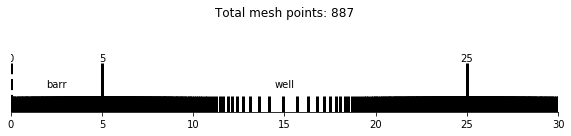

In [24]:
m.plot_mesh()
plt.xlim(0,30)

In [25]:
m.ensure_function_exists("p",value=0)
m.ensure_function_exists("n",value=0)
m.ensure_function_exists("pderiv",value=0)
m.ensure_function_exists("nderiv",value=0)
m.ensure_function_exists("fc",value=0)

In [26]:
barr,shm,scm=m.submesh_cover([2*nm,27*nm])

In [27]:
Equilibrium(m)
#Linear_Fermi(m,contacts={'gate':0,'idw':1,'source':2,'subs':3}).solve(**dict(gate=-5,idw=0,source=0,subs=0))
psm=PoissonSolver(m)
sc=SelfConsistentLoop(fieldsolvers=[psm],carriersolvers=[Semiclassical(barr),Schrodinger(shm),Semiclassical(scm)],)

In [28]:
sc.ramp_epsfactor(start=1e3,max_iter=20,dlefmin=.005)

Starting eps factor ramp from 1000 to 1
  Eps factor: 1.00e+03
  Starting SC loop
    iter:   0  err: 8.01e-12  activ: 1
    Loop finished in  1 iterations with err=8.0133e-12
  Eps factor: 6.31e+02
  Starting SC loop
    iter:   0  err: 1.01e-02  activ: 1
    iter:   1  err: 7.47e-12  activ: 1
    Loop finished in  2 iterations with err=7.47486e-12
  Eps factor: 2.51e+02
  Starting SC loop
    iter:   0  err: 4.14e-02  activ: 1
    iter:   1  err: 7.54e-10  activ: 1
    Loop finished in  2 iterations with err=7.53837e-10
  Eps factor: 7.94e+01
  Starting SC loop
    iter:   0  err: 1.49e-01  activ: 1
    iter:   1  err: 1.54e-06  activ: 1
    iter:   2  err: 1.92e-14  activ: 1
    Loop finished in  3 iterations with err=1.91718e-14
  Eps factor: 2.51e+01
  Starting SC loop
    iter:   0  err: 4.70e-01  activ: 1
    iter:   1  err: 5.42e-01  activ: 1
    Retrying with Poisson activation=0.5
           iter:   1  err: 9.27e-02
    iter:   2  err: 2.11e-02  activ: 0.6
    iter:   3  err:

In [29]:
if 0:
    mbkp=MultibandKP(shm,ktmax=2.5,num_kpoints=30)
    # This is some sort of boundary condition not sure what... not huge effect on density
    for H in mbkp._H:
        H[:6,:6]*=2
        H[-6:,-6:]*=2
    scl=SelfConsistentLoop(fieldsolvers=[psm],carriersolvers=[mbkp,Semiclassical(shm,'electron'),Semiclassical(scm)])
    scl.loop(tol=1e-8)

Text(0.5,0,'Energy [eV]')

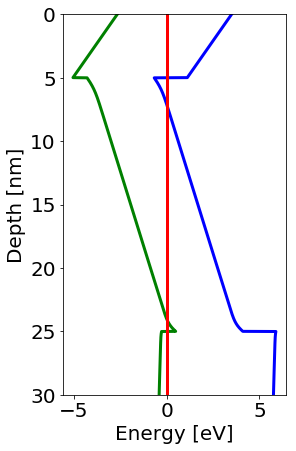

In [35]:
plt.figure(figsize=(4,7))
plt.plot(mon.Ec,mon.zp)
plt.plot(mon.Ev,mon.zp)
plt.plot(mon.EF,mon.zp)
plt.ylim(30,0)
plt.ylabel("Depth [nm]")
plt.xlabel("Energy [eV]")

# N-polar

In [5]:
m=mon=Mesh(
    [
        MaterialBlock(AlGaN(),[
            UniformLayer("barr",5*nm,x=1),
            UniformLayer("well",5*nm),
            UniformLayer("subs",500*nm,x=1,DeepAcceptorAcceptorConc=5.0e16/cm**3)
        ])
    ],
    max_dz=10*nm,
    refinements=[["barr/well",.01*nm,1.6],["well/subs",.01*nm,1.6]],
    boundary=[3.5*eV,'thick']
)
m.ztrans=1
for sm in m._submeshes:
    sm.ztrans=1

(0, 30)

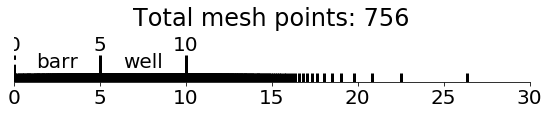

In [6]:
m.plot_mesh()
plt.xlim(0,30)

In [7]:
m.ensure_function_exists("p",value=0)
m.ensure_function_exists("n",value=0)
m.ensure_function_exists("pderiv",value=0)
m.ensure_function_exists("nderiv",value=0)
m.ensure_function_exists("fc",value=0)

In [8]:
barr,shm,scm=m.submesh_cover([2*nm,27*nm])

In [9]:
Equilibrium(m)
#Linear_Fermi(m,contacts={'gate':0,'idw':1,'source':2,'subs':3}).solve(**dict(gate=-5,idw=0,source=0,subs=0))
psm=PoissonSolver(m)
sc=SelfConsistentLoop(fieldsolvers=[psm],carriersolvers=[Semiclassical(barr),Schrodinger(shm),Semiclassical(scm)],)

In [10]:
sc.ramp_epsfactor(start=1e3,max_iter=20,dlefmin=.005)

Starting eps factor ramp from 1000 to 1
  Eps factor: 1.00e+03
  Starting SC loop
    iter:   0  err: 4.04e-16  activ: 1
    Loop finished in  1 iterations with err=4.04458e-16
  Eps factor: 6.31e+02
  Starting SC loop
    iter:   0  err: 2.53e-03  activ: 1
    iter:   1  err: 7.91e-15  activ: 1
    Loop finished in  2 iterations with err=7.90529e-15
  Eps factor: 2.51e+02
  Starting SC loop
    iter:   0  err: 1.03e-02  activ: 1
    iter:   1  err: 3.37e-15  activ: 1
    Loop finished in  2 iterations with err=3.37432e-15
  Eps factor: 7.94e+01
  Starting SC loop
    iter:   0  err: 3.72e-02  activ: 1
    iter:   1  err: 7.41e-14  activ: 1
    Loop finished in  2 iterations with err=7.41214e-14
  Eps factor: 2.51e+01
  Starting SC loop
    iter:   0  err: 1.18e-01  activ: 1
    iter:   1  err: 1.86e-13  activ: 1
    Loop finished in  2 iterations with err=1.86215e-13
  Eps factor: 7.94e+00
  Starting SC loop
    iter:   0  err: 3.72e-01  activ: 1
    iter:   1  err: 2.78e-13  activ: 1

Text(0.5,0,'Energy [eV]')

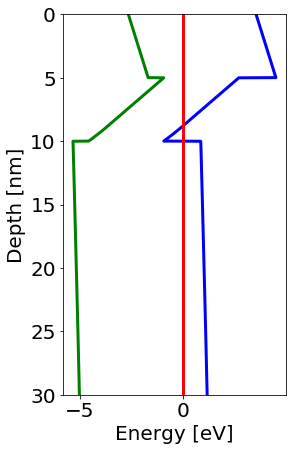

In [12]:
plt.figure(figsize=(4,7))
plt.plot(mon.Ec,mon.zp)
plt.plot(mon.Ev,mon.zp)
plt.plot(mon.EF,mon.zp)
plt.ylim(30,0)
plt.ylabel("Depth [nm]")
plt.xlabel("Energy [eV]")